# Hypothesis tests, power and the ways they go wrong

Small examples first, simulation second, real data last.

**What's in here**
- what a null hypothesis is, and a p-value built by simulation
- permutation test from scratch
- type I error, type II error, power, "how many days do I need?"
- one-sided vs two-sided, paired vs unpaired, rank tests
- multiple comparisons: Bonferroni and Benjamini–Hochberg by hand
- optional stopping (peeking)
- significance vs effect size
- regression t-statistics under autocorrelation, Newey–West by hand
- normality tests at large n, a Bayesian one-liner
- what to say in the interview

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

## 1. The logic of a null hypothesis

Two groups of 5. Group B's mean is higher. Question: could that happen by chance if both
groups came from the same distribution? That "same distribution" world is the null hypothesis H0.

In [2]:
a = np.array([10.0, 12.0, 11.0, 13.0, 9.0])
b = np.array([14.0, 15.0, 13.0, 16.0, 12.0])
observed = b.mean() - a.mean()
print("mean a:", a.mean(), " mean b:", b.mean(), " observed difference:", observed)

mean a: 11.0  mean b: 14.0  observed difference: 3.0


Simulate the H0 world: draw both groups from the same normal, and record the difference.
Five draws first, so you see what one simulated difference looks like.

In [3]:
for i in range(5):
    a_sim = rng.normal(12, 2, size=5)
    b_sim = rng.normal(12, 2, size=5)
    print("simulated difference:", round(b_sim.mean() - a_sim.mean(), 3))

simulated difference: -0.546
simulated difference: -1.576
simulated difference: 0.646
simulated difference: -0.41
simulated difference: 0.436


In [4]:
diffs = np.empty(10_000)
for i in range(10_000):
    diffs[i] = rng.normal(12, 2, size=5).mean() - rng.normal(12, 2, size=5).mean()
p_sim = (np.abs(diffs) >= observed).mean()
print("P(|difference| >= 3 under H0):", p_sim)

P(|difference| >= 3 under H0): 0.0196


That is a p-value: the probability of a result at least as extreme as the one observed,
**if H0 were true**. It is not the probability that H0 is true.

The t-test gives the same kind of number from a formula:

In [5]:
stats.ttest_ind(b, a, equal_var=False)

TtestResult(statistic=3.0, pvalue=0.017071681233782634, df=8.0)

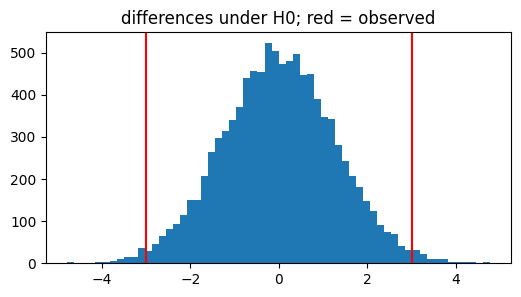

In [6]:
plt.figure(figsize=(6, 3))
plt.hist(diffs, bins=60)
plt.axvline(observed, color="r"); plt.axvline(-observed, color="r")
plt.title("differences under H0; red = observed"); plt.show()

## 2. Permutation test from scratch

Instead of assuming a distribution, shuffle the group labels. If the labels do not matter
(H0), any relabelling is as likely as the real one.

In [7]:
values = np.concatenate([a, b])
labels = np.array(["a"] * 5 + ["b"] * 5)
print("values :", values)
print("labels :", labels)

values : [10. 12. 11. 13.  9. 14. 15. 13. 16. 12.]
labels : ['a' 'a' 'a' 'a' 'a' 'b' 'b' 'b' 'b' 'b']


In [8]:
shuffled = rng.permutation(labels)
print("one permutation:", shuffled)
diff_perm = values[shuffled == "b"].mean() - values[shuffled == "a"].mean()
print("difference under this relabelling:", round(diff_perm, 3))

one permutation: ['a' 'a' 'b' 'a' 'b' 'a' 'b' 'a' 'b' 'b']
difference under this relabelling: 0.2


In [9]:
perm_diffs = np.empty(10_000)
for i in range(10_000):
    sh = rng.permutation(labels)
    perm_diffs[i] = values[sh == "b"].mean() - values[sh == "a"].mean()
print("permutation p-value:", (np.abs(perm_diffs) >= observed).mean())

permutation p-value: 0.0365


On real data: weekend vs weekday consumption.

**Pitfall:** permuting hourly rows treats each hour as independent. Hours in the same day
move together, so the null spread is far too small and p is "zero". Use daily means.

In [10]:
df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
daily = df["consumption_mwh"].resample("D").mean()
is_weekend = np.asarray(daily.index.dayofweek >= 5)
obs = daily[is_weekend].mean() - daily[~is_weekend].mean()
print("days:", len(daily), " observed weekend - weekday:", round(obs, 0))

days: 730  observed weekend - weekday: -2082.0


In [11]:
vals = daily.values
perm = np.empty(5000)
for i in range(5000):
    sh = rng.permutation(is_weekend)
    perm[i] = vals[sh].mean() - vals[~sh].mean()
print("sd of null differences:", round(perm.std(), 0))
print("permutation p-value   :", (np.abs(perm) >= abs(obs)).mean())

sd of null differences: 182.0
permutation p-value   : 0.0


## 3. Type I error, type II error, power

- Type I: reject H0 when it is true. Its rate should equal α (0.05).
- Type II: fail to reject when there is a real effect.
- Power = 1 − type II rate.

One case by hand: n = 20 per group, true effect 0.5 sd. Run the test 2,000 times.

In [12]:
n, effect = 20, 0.5
rejections_h0 = 0
rejections_h1 = 0
for i in range(2000):
    a0 = rng.normal(0, 1, n); b0 = rng.normal(0, 1, n)            # H0 true
    rejections_h0 += stats.ttest_ind(a0, b0).pvalue < 0.05
    a1 = rng.normal(0, 1, n); b1 = rng.normal(effect, 1, n)       # real effect
    rejections_h1 += stats.ttest_ind(a1, b1).pvalue < 0.05
print("type I rate (H0 true)     :", rejections_h0 / 2000, " (should be ~0.05)")
print("power (effect = 0.5 sd)   :", rejections_h1 / 2000)

type I rate (H0 true)     : 0.05  (should be ~0.05)
power (effect = 0.5 sd)   : 0.334


Now a table over n and effect size.

In [13]:
rows = []
for n in [10, 20, 50, 200]:
    for effect in [0.2, 0.5, 1.0]:
        p_vals = np.empty(500)
        for i in range(500):
            p_vals[i] = stats.ttest_ind(rng.normal(0, 1, n), rng.normal(effect, 1, n)).pvalue
        rows.append({"n per group": n, "effect (sd)": effect, "power": (p_vals < 0.05).mean()})
pd.DataFrame(rows).pivot(index="n per group", columns="effect (sd)", values="power")

effect (sd),0.2,0.5,1.0
n per group,,,
10,0.060,0.182,0.556
20,0.082,0.316,0.910
50,0.176,0.698,0.998
200,0.520,0.998,1.000


**"How many days of A/B testing to detect a 2% RMSE improvement?"**
Paired daily errors of two models; the difference has some sd. Power formula for a paired
test: n ≈ ((z_α/2 + z_power) · sd / effect)².

In [14]:
effect = 0.02          # 2% improvement in daily RMSE ratio
sd_diff = 0.10         # day-to-day sd of the ratio difference (assumed)
z_alpha = stats.norm.ppf(0.975)
z_power = stats.norm.ppf(0.80)
n_days = ((z_alpha + z_power) * sd_diff / effect) ** 2
print("z_alpha:", round(z_alpha, 3), " z_power:", round(z_power, 3))
print("days needed for 80% power:", int(np.ceil(n_days)))

z_alpha: 1.96  z_power: 0.842
days needed for 80% power: 197


## 4. One-sided vs two-sided, paired vs unpaired, rank tests

Two-sided asks "different?", one-sided asks "greater?". One-sided p is half the two-sided p
when the effect is in the expected direction.

In [15]:
print("two-sided:", round(stats.ttest_ind(b, a).pvalue, 4))
print("one-sided:", round(stats.ttest_ind(b, a, alternative="greater").pvalue, 4))

two-sided: 0.0171
one-sided: 0.0085


Paired: two models scored on the **same** 6 days. The day-to-day level moves both, so
the pairing removes that noise.

In [16]:
model_a = np.array([100.0, 130.0, 90.0, 150.0, 110.0, 120.0])
model_b = model_a - 5 + np.array([1.0, -1.0, 0.5, -0.5, 1.0, -1.0])   # always ~5 better
print("daily errors A:", model_a)
print("daily errors B:", model_b)
print("differences   :", model_a - model_b)

daily errors A: [100. 130.  90. 150. 110. 120.]
daily errors B: [ 96.  124.   85.5 144.5 106.  114. ]
differences   : [4.  6.  4.5 5.5 4.  6. ]


In [17]:
print("unpaired p:", round(stats.ttest_ind(model_a, model_b).pvalue, 4))
print("paired   p:", round(stats.ttest_rel(model_a, model_b).pvalue, 6))

unpaired p: 0.6927
paired   p: 5e-05


The unpaired test sees two noisy groups and cannot tell them apart; the paired test sees
six differences all near 5.

Rank tests do not care about the size of the values, only their order. Useful with outliers.

In [18]:
a_out = np.array([10.0, 12.0, 11.0, 13.0, 90.0])     # one outlier
b_out = np.array([14.0, 15.0, 13.0, 16.0, 12.0])
print("t-test        p:", round(stats.ttest_ind(b_out, a_out, equal_var=False).pvalue, 4))
print("Mann-Whitney  p:", round(stats.mannwhitneyu(b_out, a_out).pvalue, 4))
print("Wilcoxon paired p:", round(stats.wilcoxon(model_a, model_b).pvalue, 4))

t-test        p: 0.4483
Mann-Whitney  p: 0.2933
Wilcoxon paired p: 0.0312


## 5. Multiple comparisons

Five p-values from five tests. At α = 0.05 each has a 5% chance of a false positive.

In [19]:
p = np.array([0.010, 0.030, 0.040, 0.200, 0.600])
print("p-values:", p)
print("naive: significant =", (p < 0.05).sum())

p-values: [0.01 0.03 0.04 0.2  0.6 ]
naive: significant = 3


Bonferroni: threshold = α / m.

In [20]:
m = len(p)
print("bonferroni threshold:", 0.05 / m)
print("significant         :", (p < 0.05 / m).sum())

bonferroni threshold: 0.01
significant         : 0


Benjamini–Hochberg: sort the p-values; the k-th smallest passes if p ≤ k/m · α; every
p-value up to the largest passing k is declared significant.

In [21]:
p_sorted = np.sort(p)
for k in range(1, m + 1):
    thr = k / m * 0.05
    print(f"k={k}  p={p_sorted[k-1]:.3f}  k/m*alpha={thr:.3f}  pass={p_sorted[k-1] <= thr}")

k=1  p=0.010  k/m*alpha=0.010  pass=True
k=2  p=0.030  k/m*alpha=0.020  pass=False
k=3  p=0.040  k/m*alpha=0.030  pass=False
k=4  p=0.200  k/m*alpha=0.040  pass=False
k=5  p=0.600  k/m*alpha=0.050  pass=False


In [22]:
print("BH-adjusted p-values:", stats.false_discovery_control(p).round(3))

BH-adjusted p-values: [0.05  0.067 0.067 0.25  0.6  ]


Now at scale: 50 random features vs a random target.

In [23]:
target = rng.normal(size=200)
p_vals = np.empty(50)
for j in range(50):
    p_vals[j] = stats.pearsonr(rng.normal(size=200), target)[1]
print("features with p < 0.05 :", (p_vals < 0.05).sum(), "of 50 (expected 2.5)")
print("after BH               :", (stats.false_discovery_control(p_vals) < 0.05).sum())

features with p < 0.05 : 2 of 50 (expected 2.5)
after BH               : 0


**The "best of 20 variants" trap.** Try 20 model variants that are all pure noise, keep
the best, test it: how often does the winner look significant?

In [24]:
wins = 0
for trial in range(1000):
    gains = rng.normal(0, 1, size=(20, 30))          # 20 variants x 30 days of "gain", true mean 0
    best = gains[gains.mean(axis=1).argmax()]        # pick the best variant
    wins += stats.ttest_1samp(best, 0).pvalue < 0.05
print("winner 'significant' in", wins / 1000, "of trials (should be 0.05)")

winner 'significant' in 0.389 of trials (should be 0.05)


## 6. Optional stopping

Peek at the p-value every 10 observations and stop as soon as p < 0.05. Under H0 the
false-positive rate balloons.

In [25]:
false_pos_single = 0
false_pos_peeking = 0
for trial in range(2000):
    x = rng.normal(0, 1, size=500)
    false_pos_single += stats.ttest_1samp(x, 0).pvalue < 0.05
    for n in range(10, 501, 10):
        if stats.ttest_1samp(x[:n], 0).pvalue < 0.05:
            false_pos_peeking += 1
            break
print("single look at n=500  :", false_pos_single / 2000)
print("peeking every 10      :", false_pos_peeking / 2000)

single look at n=500  : 0.0515
peeking every 10      : 0.3245


## 7. Significance vs effect size

With enough data everything is "significant". Two groups differing by 0.3% of their level,
n = 100,000 each:

In [26]:
n = 100_000
g1 = rng.normal(100, 10, n)
g2 = rng.normal(100.3, 10, n)
res = stats.ttest_ind(g1, g2)
print("difference:", round(g2.mean() - g1.mean(), 3), " p-value:", res.pvalue)

difference: 0.362  p-value: 5.585231054756671e-16


Report the effect with a confidence interval, in units that mean something:

In [27]:
diff = g2.mean() - g1.mean()
se = np.sqrt(g1.var(ddof=1) / n + g2.var(ddof=1) / n)
print("difference:", round(diff, 3), " 95% CI:", round(diff - 1.96 * se, 3), "to", round(diff + 1.96 * se, 3))
print("Cohen's d :", round(diff / np.sqrt((g1.var(ddof=1) + g2.var(ddof=1)) / 2), 4), " (0.2 is 'small')")

difference: 0.362  95% CI: 0.274 to 0.45
Cohen's d : 0.0362  (0.2 is 'small')


## 8. Regression t-statistics under autocorrelation

The OLS t-statistic assumes independent residuals. Time-series residuals are not.

Start with 6 residuals and compute the lag-1 autocovariance by hand.

In [28]:
r = np.array([1.0, 2.0, 1.5, -0.5, -1.0, -0.5])
r_c = r - r.mean()
gamma0 = (r_c * r_c).mean()                       # variance
gamma1 = (r_c[1:] * r_c[:-1]).sum() / len(r)      # lag-1 autocovariance
print("centred      :", r_c)
print("gamma0 (var) :", round(gamma0, 4))
print("gamma1       :", round(gamma1, 4))
print("rho1         :", round(gamma1 / gamma0, 4))

centred      : [ 0.5833  1.5833  1.0833 -0.9167 -1.4167 -0.9167]
gamma0 (var) : 1.2847
gamma1       : 0.7072
rho1         : 0.5505


Newey–West with one lag: long-run variance = γ₀ + 2 · (1 − 1/2) · γ₁. The Bartlett weight
(1 − k/(L+1)) shrinks higher lags.

In [29]:
L = 1
lrv = gamma0 + 2 * (1 - 1 / (L + 1)) * gamma1
print("iid variance     :", round(gamma0, 4))
print("long-run variance:", round(lrv, 4))

iid variance     : 1.2847
long-run variance: 1.9919


Now the damage in a regression. Both x and the noise are AR(1) with ρ = 0.9 (a slowly
moving regressor like temperature, and slowly moving errors), and the true slope is 0.
Compare the iid t-statistic's false-positive rate against a Newey–West one.

In [30]:
n = 300
false_iid = 0
false_nw = 0
for trial in range(500):
    x = np.empty(n); e = np.empty(n)
    x[0] = rng.normal(); e[0] = rng.normal()
    for t in range(1, n):
        x[t] = 0.9 * x[t - 1] + rng.normal()
        e[t] = 0.9 * e[t - 1] + rng.normal()
    y = e                                            # slope truly 0
    X = np.column_stack([np.ones(n), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    # iid se
    sigma2 = (resid**2).sum() / (n - 2)
    XtX_inv = np.linalg.inv(X.T @ X)
    se_iid = np.sqrt(sigma2 * XtX_inv[1, 1])
    # Newey-West se with L lags, Bartlett weights
    L = 10
    u = X * resid[:, None]
    S = u.T @ u
    for k in range(1, L + 1):
        w = 1 - k / (L + 1)
        S += w * (u[k:].T @ u[:-k] + u[:-k].T @ u[k:])
    V = XtX_inv @ S @ XtX_inv
    se_nw = np.sqrt(V[1, 1])
    false_iid += abs(beta[1] / se_iid) > 1.96
    false_nw += abs(beta[1] / se_nw) > 1.96
print("false-positive rate, iid se        :", false_iid / 500)
print("false-positive rate, Newey-West se :", false_nw / 500)

false-positive rate, iid se        : 0.486
false-positive rate, Newey-West se : 0.174


With independent errors both rates would be 0.05. The iid rate is several times too high;
Newey–West brings it most of the way back (it is itself an approximation at L = 10).

**Interview check:** "Your regression of price on temperature has t = 8. Do you believe it?"
Ask whether the residuals are autocorrelated (`pd.Series(resid).autocorr(1)`); if they are,
the iid t-statistic is inflated and needs a Newey–West or block-bootstrap standard error.

## 9. Normality tests at large n, and a Bayesian one-liner

`jarque_bera` on hourly price changes rejects at any n because the kurtosis is huge.
That is a fact about the data, not a problem to fix.

In [31]:
dp = df["price_eur_mwh"].diff().dropna().values
for n in [50, 500, 5000]:
    print(f"n={n:5d}  kurtosis={stats.kurtosis(dp[:n]):6.1f}  jarque_bera p={stats.jarque_bera(dp[:n]).pvalue:.3g}")

n=   50  kurtosis=   4.6  jarque_bera p=1.29e-10
n=  500  kurtosis=  21.9  jarque_bera p=0
n= 5000  kurtosis=  17.2  jarque_bera p=0


Bayesian framing for a hit rate: 58 correct directions out of 100. With a flat Beta(1, 1)
prior the posterior is Beta(59, 43).

In [32]:
posterior = stats.beta(1 + 58, 1 + 42)
print("posterior mean          :", round(posterior.mean(), 3))
print("95% credible interval   :", np.round(posterior.interval(0.95), 3))
print("P(hit rate > 0.5)       :", round(1 - posterior.cdf(0.5), 3))

posterior mean          : 0.578
95% credible interval   : [0.482 0.672]
P(hit rate > 0.5)       : 0.945


## What to say when asked "is this significant?"

1. What is the unit of observation, and are the units independent? (hours are not)
2. What is the null, and which test matches it? (paired if same days)
3. What is the effect size with a confidence interval, in real units?
4. How many things were tried before this one? (multiple comparisons)
5. Was the stopping rule fixed in advance?
6. Does it hold out of sample / in each sub-period?

## Quick reference

| Task | Call |
|---|---|
| two independent means | `stats.ttest_ind(a, b, equal_var=False)` |
| same units, two conditions | `stats.ttest_rel(a, b)` |
| one-sided | `alternative="greater"` |
| ranks | `stats.mannwhitneyu`, `stats.wilcoxon` |
| permutation test | shuffle labels, recompute statistic, compare |
| multiple tests | `stats.false_discovery_control(p)` |
| power (paired, normal) | n ≈ ((z_α/2 + z_pow)·sd/effect)² |
| autocorrelated regression | Newey–West se or block bootstrap |
| Bayesian hit rate | `stats.beta(1 + hits, 1 + misses)` |